# Hacer hello world en mitsuba

In [38]:
import mitsuba as mi
import drjit as dr

import plotly.graph_objects as go
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import matplotlib.pyplot as plt
import numpy as np

In [10]:
mi.set_variant('cuda_ad_rgb')

img = mi.render(mi.load_dict(mi.cornell_box()))

bitmap = mi.Bitmap(img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.493814].


(256, 256, 3)


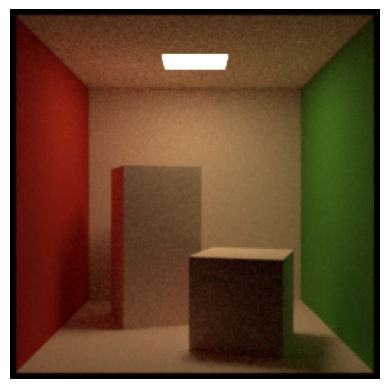

In [12]:
img_np = np.array(bitmap.convert(srgb_gamma=True))
print(img_np.shape)
#img_np = 255*(img_np - img_np.min())/(img_np.max() - img_np.min())
#img_np = img_np.astype(np.uint8)

plt.imshow(img_np)
plt.axis('off')
plt.show()

In [103]:
mi.set_variant('cuda_ad_rgb')

scene = mi.load_dict(mi.cornell_box())

shapes = scene.shapes()

print(f"Numero de formas {len(shapes)}")

for shape in shapes:
    mesh = mi.traverse(shape)
    print(f"Nombre: {shape.id()}")
    print(f"Tipo: {shape.class_().name()}")
    print(f"Propiedades: {list(mesh.keys())}")
    if 'vertex_positions' in mesh:
        print(f"Vertices positions: \n{mesh['vertex_positions'].shape}")
    if 'vertex_texcoords' in mesh:
        print(f"Vertices texcoord: \n{mesh['vertex_texcoords'].shape}")
    if 'vertex_normals' in mesh:
        print(f"Vertices normals: \n{mesh['vertex_normals'].shape}")
    print()

Numero de formas 8
Nombre: back
Tipo: Rectangle
Propiedades: ['bsdf.reflectance.value', 'silhouette_sampling_weight', 'to_world']

Nombre: ceiling
Tipo: Rectangle
Propiedades: ['bsdf.reflectance.value', 'silhouette_sampling_weight', 'to_world']

Nombre: floor
Tipo: Rectangle
Propiedades: ['bsdf.reflectance.value', 'silhouette_sampling_weight', 'to_world']

Nombre: green-wall
Tipo: Rectangle
Propiedades: ['bsdf.reflectance.value', 'silhouette_sampling_weight', 'to_world']

Nombre: large-box
Tipo: Cube
Propiedades: ['bsdf.reflectance.value', 'silhouette_sampling_weight', 'faces', 'vertex_positions', 'vertex_normals', 'vertex_texcoords']
Vertices positions: 
(72,)
Vertices texcoord: 
(48,)
Vertices normals: 
(72,)

Nombre: light
Tipo: Rectangle
Propiedades: ['bsdf.reflectance.value', 'emitter.sampling_weight', 'emitter.radiance.value', 'silhouette_sampling_weight', 'to_world']

Nombre: red-wall
Tipo: Rectangle
Propiedades: ['bsdf.reflectance.value', 'silhouette_sampling_weight', 'to_world

In [33]:
for shape in shapes:
    mesh = mi.traverse(shape)
    
    if 'vertex_positions' in mesh:  # Solo si el objeto tiene vértices
        vtx = mesh['vertex_positions']
        idx = mesh['faces']
        print(f"Nombre: {shape.id()}, Vértices: {vtx.numpy().shape}, Caras: {idx.numpy().shape}")
        
    else:
        print(f"Nombre: {shape.id()} no tiene vértices.")
        


Nombre: back no tiene vértices.
Nombre: ceiling no tiene vértices.
Nombre: floor no tiene vértices.
Nombre: green-wall no tiene vértices.
Nombre: large-box, Vértices: (72,), Caras: (36,)
Nombre: light no tiene vértices.
Nombre: red-wall no tiene vértices.
Nombre: small-box, Vértices: (72,), Caras: (36,)


In [105]:
# Crear listas para los datos de las mallas
all_vertices = []
all_faces = []

# Recorrer las formas en la escena
for shape in shapes:
    mesh = mi.traverse(shape)
    
    # Verificar si el objeto tiene vértices (solo los cubos los tienen)
    if 'vertex_positions' in mesh:
        vtx = mesh['vertex_positions'].numpy().reshape(-1,3)  # Convertir a numpy, 3 de las 3 dimensiones
        idx = mesh['faces'].numpy().reshape(-1,3)  # Convertir a numpy, y 4 de 4 vertices por cara
        
        # Agregar a las listas
        all_vertices.append(vtx)
        all_faces.append(idx)


# Verificar las dimensiones de cada conjunto de datos
for i, (vtx, idx) in enumerate(zip(all_vertices, all_faces)):
    print(f"Malla {i}: vértices shape {vtx.shape}, caras shape {idx.shape}")

Malla 0: vértices shape (24, 3), caras shape (12, 3)
Malla 1: vértices shape (24, 3), caras shape (12, 3)


Faces shape: (12, 3)
Vertices shape: (24, 3)
Faces shape: (12, 3)
Vertices shape: (24, 3)


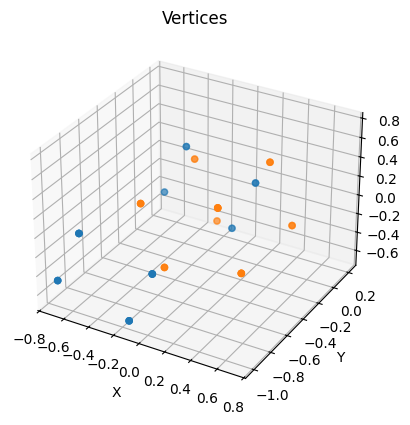

In [107]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for vertices, faces in zip(all_vertices, all_faces):
    # 🔹 Verificar forma de 'faces'
    print(f"Faces shape: {faces.shape}")
    print(f"Vertices shape: {vertices.shape}")

    # Graficar las vertices
    ax.scatter(vertices[:,0], vertices[:,1], vertices[:,2])


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Vertices")

plt.show()



Mash faces shape: (12, 3, 3)
Mash faces shape: (12, 3, 3)


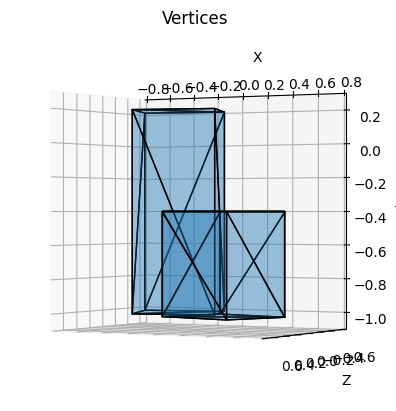

In [146]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for vertices, faces in zip(all_vertices, all_faces):
    mash_faces = []
    for face in faces:
        mash_faces.append([vertices[face[0]], vertices[face[1]], vertices[face[2]]])
    mash_faces = np.array(mash_faces)
    
    print(f"Mash faces shape: {mash_faces.shape}")

    for face in mash_faces:
        # Crear una colección de polígonos
        poly3d = [[face[0], face[1], face[2]]]
        pc = Poly3DCollection(poly3d, alpha=.25, linewidths=1, edgecolors='k')
        ax.add_collection3d(pc)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Vertices")

ax.view_init(elev=60, azim=0, roll=90)

plt.show()

